# <center> Git. Основные операции

**Рабочая директория** — файловая система проекта (те файлы, с которыми вы работаете).

**Индекс** — список отслеживаемых Git-файлов и директорий, промежуточное хранилище изменений (редактирование, удаление отслеживаемых файлов).

**Директория .git/** — в этой локальной директории хранятся все данные контроля версий проекта (вся история разработки — коммиты, ветки, теги и пр.).

* git config

Команда ```config``` предназначена для настройки параметров Git на вашем компьютере.

Например, первое, что вам следует сделать после установки Git — указать ваше имя и адрес электронной почты. Это важно, потому что каждый коммит в Git содержит эту информацию и она не может быть далее изменена. Без указания этой информации основные команды Git будут работать, но коммиты будут создаваться без информации об авторе, что может вызвать трудности при совместной работе.

Если вы не сделали этого ранее, когда устанавливали Git, или захотели поменять настройки, рекомендуем сделать это сейчас. Для этого необходимо указать ключ ```--global``` (глобальные изменения) и передать в команду аргументы user.name и user.email:

```python
git config --global user.name "Your Name"
git config --global user.email "your_email@whatever.com"
    

Примечание. Следующая команда выведет список всех ваших настроек, включая имя и почту:

```python
git config –-list

------

* git init

Данная команда инициализирует локальный репозиторий. По сути, она создаёт пустой репозиторий на вашем компьютере.

---

* git clone

Команда clone — другой вариант инициализации репозитория из уже существующего с помощью копирования. Её общий синтаксис:
``` python
git clone [ссылка на репозиторий]

Данная операция пригодится вам, если все файлы вашего проекта уже где-то существуют.
Клонировать можно как локальный (находящийся на вашем компьютере), так и удалённый (находящийся на GitHub) репозиторий.

---

* git add

Команда add добавляет файл (папку с файлами) в индекс (иногда говорят «индексирует»), то есть добавляет его в список отслеживаемых для системы контроля версий. Нужно указать в аргументах, какой файл или папку мы хотим добавить.

Примеры:
* git add README.md — добавляет файл README.md в индекс.
* git add data/ — добавляет папку data и всё её содержимое в индекс.

Чаще всего нам нужно добавить все файлы в текущем каталоге в индекс (кроме игнорируемых, о которых мы поговорим ниже). Для этого используется команда
* git add .

-----

* git reset

позволяет убрать файлы (папки с файлами) из списка отслеживаемых.

Примеры:
* git reset README.md — удаляет файл README.md из индекса.
* git reset data/ — удаляет папку data из индекса.

Чтобы убрать из индекса все файлы из текущей директории, используйте точку:
* git reset .

-------

* git commit

Коммит — это операция сохранения набора изменений, сделанного в рабочей директории с момента предыдущего коммита. Коммит неизменен, его нельзя отредактировать — можно только отменить.

Команда commit откроет текстовый редактор для ввода сообщения коммита. Также эта команда принимает несколько аргументов:
* -m позволяет написать сообщение вместе с командой, не открывая текстовый редактор.
Обычно в сообщении указывается задача, которая решается этим обновлением, например «инициализация», «добавление счетов» или «исправление ошибки создания счёта».

Пример:
``` python
git commit -m "fixed bag in function clean_data"
```
* -a переносит все отслеживаемые файлы в область подготовленных файлов и включает их в коммит.

Пример:
``` python
git commit -a -m "fixed bag in function clean_data"
```
* --amend заменяет последний коммит новым изменённым коммитом, что бывает полезно, если вы неправильно набрали сообщение последнего коммита или забыли включить в него какие-то файлы.


Каждый коммит содержит уникальную контрольную сумму (хеш) — идентификатор, который Git использует, чтобы ссылаться на коммит. Для отслеживания истории в папке .git есть файл ```HEAD```.

**HEAD** — это указатель (то есть ссылка на один из коммитов), главное назначение которого — определять, в каком состоянии находится рабочая директория. На какой коммит указывает ```HEAD```, в таком состоянии файлы и находятся в рабочей области.

Зная **HEAD** (текущий действующий коммит), мы можем перемещаться по истории коммитов.

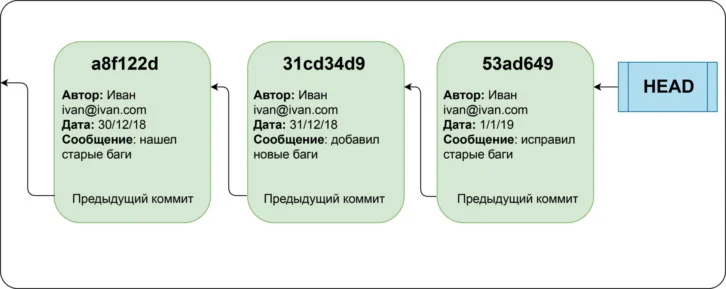

Чтобы посмотреть, на какой из коммитов указывает HEAD в данный момент, можно открыть файл HEAD в текстовом редакторе или использовать команду ```cat-file с ключом -p``` (от слова print). Пример:
``` python
git cat-file -p HEAD
```

-----

## <center> ПОЛУЧЕНИЕ ДАННЫХ О СОСТОЯНИИ РЕПОЗИТОРИЯ

* git status

Данная команда позволяет отследить состояние файлов в репозитории и узнать, какие изменения необходимо зарегистрировать Git (при необходимости — отменить).

Файл в репозитории может находиться в нескольких состояниях:

1. Отслеживаемый. Это те файлы, о которых Git знает и отслеживает изменения в них. Отслеживаемые файлы в свою очередь могут находится в следующих состояниях:

* Неизменённый. То есть с момента последнего коммита в файле не было никаких изменений.
* Изменённый. То есть с последнего коммита в файле были произведены какие-то изменения.
* Подготовленный к коммиту. Это значит, что вы внесли изменения в этот файл и затем проиндексировали файлы с внесёнными изменениями. Полученные изменения будут добавлены в следующий коммит.
2. Неотслеживаемый. О неотслеживаемых файлах Git не знает, поэтому изменения в них не будут добавлены в коммит. Это любые файлы в вашем рабочем каталоге, которые не входили в последний коммит и не подготовлены к текущему коммиту.

Можно вывести более сжатую версию этой информации, воспользовавшись командой^
```python
git status -s
```

------

* git log

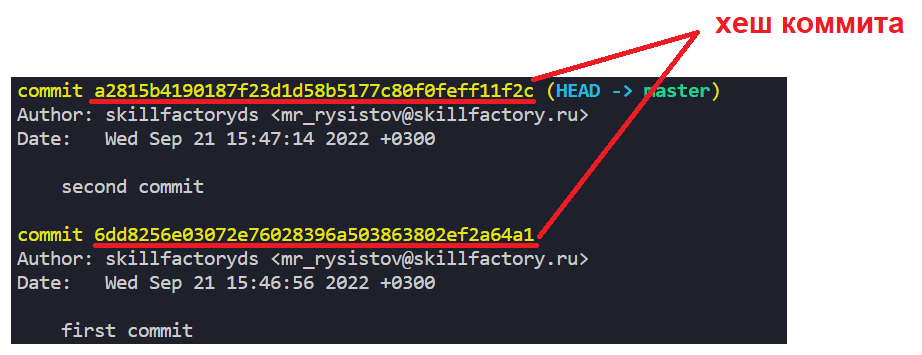

Примечание. Чтобы выйти из режима логирования, необходимо нажать "q".

------

* git show

Выполнив эту команду, вы увидите на экране информацию по определённому коммиту: кто сделал этот коммит, когда это произошло, сообщение коммита, а также сами изменения. Общий синтаксис команды:
```python
git show [хеш коммита]
```

В выводе команды show содержится информация об авторе коммита, дате коммита, а также обо всех изменениях в каждом из файлов. Просмотр изменений осуществляется в режиме текстового редактора.

Примечание. Свернуть окно просмотра после команды show можно с помощью символа "q".

---

### <center> ПЕРЕМЕЩЕНИЕ МЕЖДУ КОММИТАМИ И ОТКАТ ИЗМЕНЕНИЙ

* git checkout

Зная хеши коммитов и их историю, мы можем перемещаться между ними, то есть возвращаться к состоянию файлов в нашем проекте, зафиксированному тем или иным коммитом. В этом нам поможет команда checkout. Её общий синтаксис:
```python
git checkout [хеш коммита]
```

С точки зрения системы Git перемещение между коммитами (без дополнительных ключей) — это не что иное, как передвижение указателя HEAD.

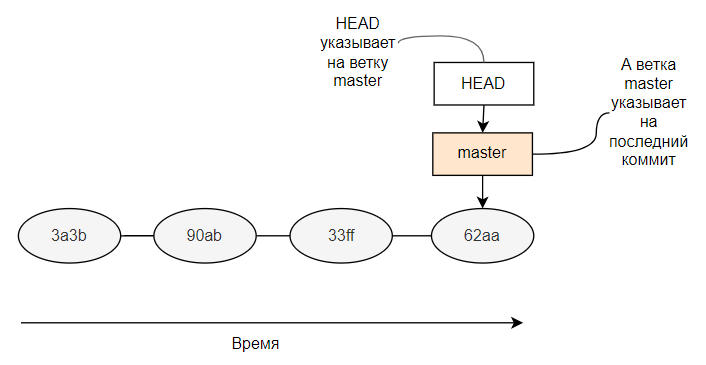

Серыми овалами обозначены коммиты (их четыре), текст на них — часть хеша соответствующего коммита. Коричневым прямоугольником обозначен указатель ветки: на приведённом примере она одна и называется master. Белым прямоугольником обозначен указатель HEAD — его-то мы и будем двигать.

Чтобы перейти к определённому коммиту, вам нужно лишь передать его хеш в качестве параметра команды checkout. Например:
```python
git checkout 90ab
```

Примечание. Для перемещения по коммитам можно использовать относительный путь. Для этого используются операторы ~ (назад по истории коммитов) и ^ (вперёд по истории коммитов), то есть предыдущую команду можно записать как:
```python
git checkout HEAD~2
```

То есть Git выдаёт предупреждение, что мы находимся в некотором состоянии, именуемом “detached head” (дословно — «отрубленная голова»). Схематично его можно изобразить так:

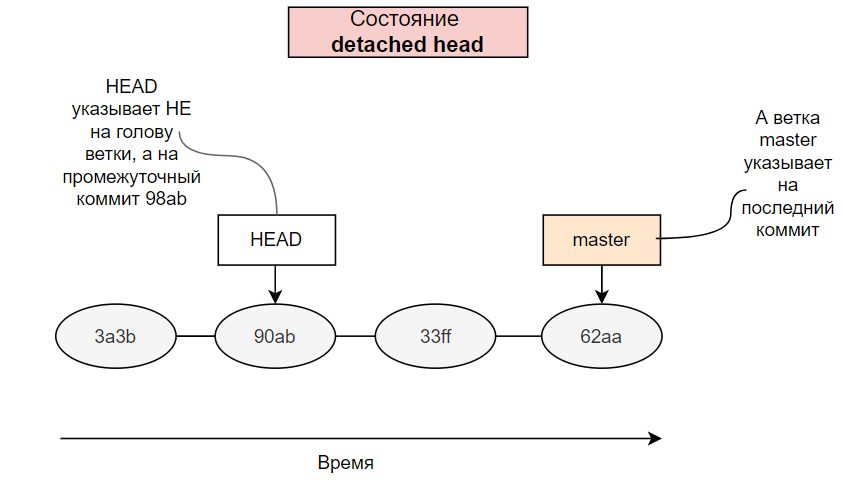

Как видно из рисунка, указатель HEAD действительно передвинут на два коммита назад. Однако указатель ветки master остался на месте и всё ещё указывает на последний коммит. Такое состояние, когда HEAD указывает не на указатель ветки, а непосредственно на сам коммит, как раз и называется detached head.

Зачем может понадобиться команда checkout?

В целом состояние detached head, которое даёт команда checkout при перемещении по коммитам, используется довольно редко. Однако всё же можно привести несколько примеров:

Самый простой пример — просмотр состояния файлов в определённом коммите.

Представим, что мы наделали ошибок в нашем проекте, причём так, что быстро переписать код уже не получится. Поэтому мы хотим откатиться назад, на одну из предыдущих версий. Однако мы не помним, какой коммит соответствует устраивающей нас версии. Тут нам и поможет checkout.

Мы можем перемещаться по истории коммитов и найти то состояние файлов, которое нас устраивает. Когда мы его найдём, нам останется вернуться на исходную позицию — переместить указатель HEAD на ветку master, а затем откатиться до интересующего нас коммита.

Кроме того, когда вы работаете над большим проектом, может возникнуть необходимость вернуться на несколько коммитов назад и создать свою ветку оттуда, например чтобы протестировать экспериментальную функцию в том состоянии проекта. О том, как создавать ветки, мы поговорим далее.

------

* git revert

Ваш проект может перестать работать после внесения изменений в код. В таком случае важно уметь быстро вернуть всё к рабочему состоянию и только потом заниматься поиском ошибки. Для этого как раз и нужна команда ```revert```.

Данная команда создаёт новый коммит, который отменяет изменения, внесённые в переданном коммите (последовательности коммитов). То есть для отмены изменений создаётся новый коммит, который «стирает» тот, который мы укажем в аргументах.

Например, команда ```git revert 62aa``` создаст новый коммит, который отменяет изменения, сделанные в коммите ```62aa```. Если мы просто выполним данную команду, будет открыт консольный редактор, чтобы вы могли отредактировать сообщение нового коммита. Можно что-то дописать, можно сразу закрыть редактор (комбинация клавиш ":" и "q"), а можно воспользоваться ключом ```--no-edit``` и оставить сообщение нового коммита по умолчанию (рекомендуется).

```python
git revert 62aa --no-edit
git revert HEAD --no-edit #отмена изменений в текущем коммите
git revert HEAD~1 --no-edit #отмена изменений в предыдущем коммите